✅ CSV file already exists: sales_data_sample.csv

🔍 Loading data...
Trying encoding: latin1...
✅ Successfully loaded with encoding: latin1
📊 Data loaded successfully (2,823 rows)

🔎 First 3 rows:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium



📝 Column structure:
ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
STATUS               object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE          object
MSRP                  int64
PRODUCTCODE          object
CUSTOMERNAME         object
PHONE                object
ADDRESSLINE1         object
ADDRESSLINE2         object
CITY                 object
STATE                object
POSTALCODE           object
COUNTRY              object
TERRITORY            object
CONTACTLASTNAME      object
CONTACTFIRSTNAME     object
DEALSIZE             object

🔤 Actual column names in CSV:
['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POS

,product,total_qty,revenue
0,S18_3232,1774,176026.63
1,S24_3856,1052,103489.89
2,S18_4600,1031,101835.00
3,S24_2300,996,99600.00
4,S18_2238,966,96300.00
...,...,...,...
104,S24_2022,851,42524.98
105,S24_2972,912,42145.94
106,S32_2206,836,39237.71
107,S24_1937,844,37392.38


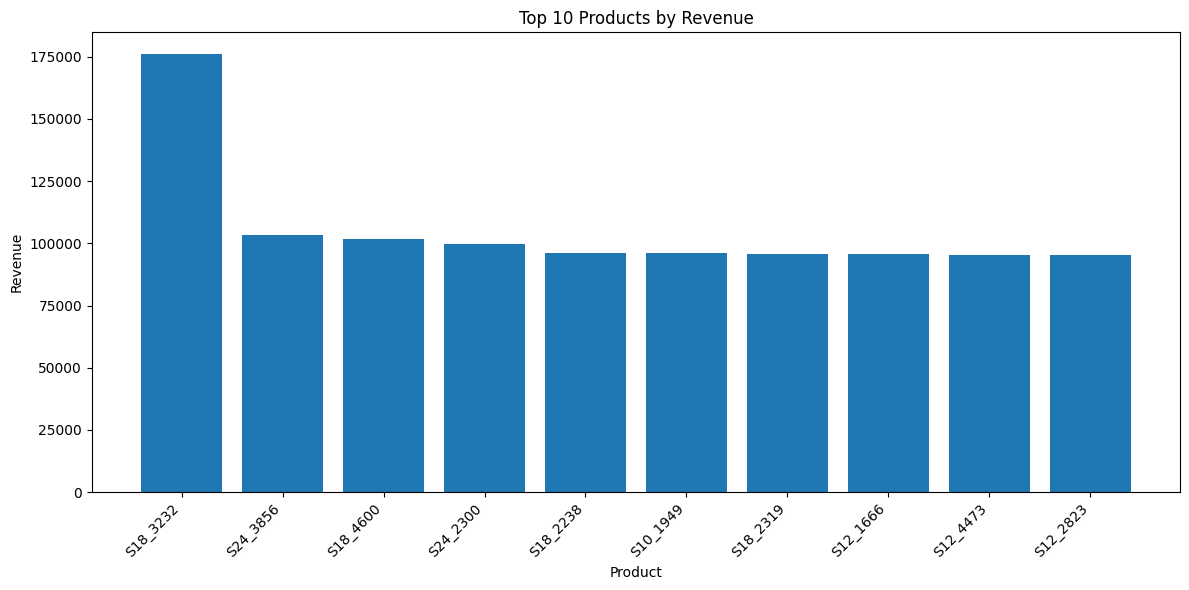

✅ Chart saved as sales_chart.png
Database connection closed.


In [7]:
# Sales Analysis Notebook
# Fixed Version

# 1. Install required packages (run once)
!pip install pandas matplotlib requests

# 2. Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import requests
import os
from IPython.display import display

# Configure matplotlib for Jupyter
%matplotlib inline

# 3. Configuration (Edit this section if needed)
CSV_URL = "https://raw.githubusercontent.com/plotly/datasets/master/sales_success.csv"  # Test dataset
CSV_FILE = "sales_data_sample.csv"
DB_FILE = "sales_data.db"
CHART_FILE = "sales_chart.png"

# 4. Download CSV (if missing)
if not os.path.exists(CSV_FILE):
    try:
        print(f"📥 Downloading dataset from {CSV_URL}...")
        response = requests.get(CSV_URL)
        response.raise_for_status()
        with open(CSV_FILE, 'wb') as f:
            f.write(response.content)
        print(f"✅ Successfully downloaded {CSV_FILE} ({len(response.content):,} bytes)")
    except Exception as e:
        print(f"❌ Download failed: {str(e)}")
        raise
else:
    print(f"✅ CSV file already exists: {CSV_FILE}")

# 5. Load and verify data
try:
    print("\n🔍 Loading data...")

    # Try different encodings
    encodings_to_try = ['latin1', 'iso-8859-1', 'cp1252', 'utf-8-sig', 'utf-8']

    for encoding in encodings_to_try:
        try:
            print(f"Trying encoding: {encoding}...")
            df = pd.read_csv(CSV_FILE, encoding=encoding)
            print(f"✅ Successfully loaded with encoding: {encoding}")
            break
        except UnicodeDecodeError:
            print(f"❌ Failed with encoding: {encoding}")
            if encoding == encodings_to_try[-1]:
                raise
            continue

    print(f"📊 Data loaded successfully ({len(df):,} rows)")
    print("\n🔎 First 3 rows:")
    display(df.head(3))
    print("\n📝 Column structure:")
    print(df.dtypes.to_string())

    # Print actual column names to debug
    print("\n🔤 Actual column names in CSV:")
    print(df.columns.tolist())

except Exception as e:
    print(f"❌ Data loading error: {str(e)}")
    raise

# 6. Database setup
try:
    print("\n🛠 Creating database...")
    conn = sqlite3.connect(DB_FILE)

    # Create table dynamically based on actual DataFrame columns
    print("Creating table with columns from DataFrame")

    # Insert data
    print("💾 Inserting data...")
    df.to_sql('sales', conn, if_exists='replace', index=False)
    print(f"✅ Database created: {DB_FILE} ({os.path.getsize(DB_FILE):,} bytes)")

    # Check the actual table schema in SQLite
    print("\n📋 Actual columns in SQLite table:")
    cursor = conn.cursor()
    cursor.execute("PRAGMA table_info(sales)")
    columns = cursor.fetchall()
    for col in columns:
        print(f"- {col[1]} ({col[2]})")

except Exception as e:
    print(f"❌ Database error: {str(e)}")
    raise

# 7. Run analysis
try:
    print("\n📈 Running analysis...")

    # Get the actual column names from the table
    cursor = conn.cursor()
    cursor.execute("PRAGMA table_info(sales)")
    columns = cursor.fetchall()
    column_names = [col[1] for col in columns]

    # Find quantity, price and product code columns based on name patterns
    qty_col = next((col for col in column_names if 'quant' in col.lower()), column_names[1])
    price_col = next((col for col in column_names if 'price' in col.lower()), column_names[2])
    product_col = next((col for col in column_names if 'product' in col.lower() and 'code' in col.lower() or 'productcode' in col.lower()), column_names[12])

    print(f"Using columns: Quantity={qty_col}, Price={price_col}, Product={product_col}")

    # Build the query using the actual column names
    query = f"""
    SELECT
        "{product_col}" AS product,
        SUM("{qty_col}") AS total_qty,
        ROUND(SUM("{qty_col}" * "{price_col}"), 2) AS revenue
    FROM sales
    GROUP BY "{product_col}"
    ORDER BY revenue DESC;
    """

    print("Executing SQL query:")
    print(query)

    results = pd.read_sql_query(query, conn)
    print("\n📊 Analysis results:")
    display(results)

    # 8. Create visualization
    plt.figure(figsize=(12, 6))
    top_products = results.head(10)  # Top 10 products
    plt.bar(top_products['product'], top_products['revenue'])
    plt.title('Top 10 Products by Revenue')
    plt.xlabel('Product')
    plt.ylabel('Revenue')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(CHART_FILE)
    plt.show()
    print(f"✅ Chart saved as {CHART_FILE}")

except Exception as e:
    print(f"❌ Analysis error: {str(e)}")
    raise

finally:
    # Close connection
    if 'conn' in locals():
        conn.close()
        print("Database connection closed.")